In [2]:
# 디바이스 설정
import torch

if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda:0") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU



# 시각화 관련 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

try:
    plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
except:
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
fm._load_fontmanager(try_read_cache=False)




# 캐시 지우기 함수 생성
import gc

def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()


# 로그
import logging

def init_logger() -> logging.Logger:
    logging.basicConfig(
        format="%(asctime)s [%(levelname)s] (%(filename)s:%(lineno)d) - %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
        level=logging.INFO,
        encoding="utf-8",
    )
    return logging.getLogger("")

logger = init_logger()

Matplotlib is building the font cache; this may take a moment.


In [3]:
# 복수 객체 이미지 확인 및 딕셔너리 반환 함수 생성
def get_label_dict(txt_file):
    global info_list

    f = open(txt_file, "r")
    lines = f.readlines()

    # \n 제거
    info_list = []
    for line in lines:
        info_list.append(line.strip())

    label_dict = dict()
    for item in info_list:
        label_dict[item.split(" ")[0]] = {
                                        "class_id": item.split(" ")[1],
                                        "species": item.split(" ")[2],
                                        "breed_id": item.split(" ")[3]
                                        }
        
    return label_dict


trainval_txt_file = "./data/annotations/annotations/trainval.txt"
test_txt_file = "./data/annotations/annotations/test.txt"

TRAIN_LABEL_DICT = get_label_dict(trainval_txt_file)
train_label_list = info_list

TEST_LABEL_DICT = get_label_dict(test_txt_file)
test_label_list = info_list


print(f"[레이블 개수]")
print(f"· 총 {len(TRAIN_LABEL_DICT) + len(TEST_LABEL_DICT)}개")
print(f"· Train : {len(TRAIN_LABEL_DICT)}개")
print(f"· Test : {len(TEST_LABEL_DICT)}개")


print(f"\n[Label Dict 샘플 출력]")
print(f"· {TRAIN_LABEL_DICT}")


# train과 test 중복 파악
train_label_set = set(TRAIN_LABEL_DICT.keys())
test_label_set = set(TEST_LABEL_DICT.keys())
print(f"\n[train - test 중복 파악]")
print(f"· Train 중복 데이터 개수: {len(train_label_set) - len(train_label_set - test_label_set)}개")
print(f"· Test 중복 데이터 개수: {len(test_label_set) - len(test_label_set - train_label_set)}개")

print("\n[복수 객체 이미지 확인]")
print(f"· Train 레이블 복수 객체: {len(train_label_list) - len(TRAIN_LABEL_DICT)}개")
print(f"· Test 레이블 복수 객체: {len(test_label_list) - len(TEST_LABEL_DICT)}개")

[레이블 개수]
· 총 7349개
· Train : 3680개
· Test : 3669개

[Label Dict 샘플 출력]
· {'Abyssinian_100': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_101': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_102': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_103': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_104': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_105': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_106': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_107': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_108': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_109': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_10': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_110': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_111': {'class_id': '1', 'species': '1', 'breed_id': '1'}, 'Abyssinian_112': 

In [4]:
import random
import glob
import xml.etree.ElementTree as ET

ANNOTS_PATH = sorted(glob.glob("./data/annotations/annotations/xmls/*.xml"))

print(f"[좌표 데이터]")
print(f"· 좌표 개수: {len(ANNOTS_PATH)}개")


# xml 하위 요소 출력 함수 생성
def crawl_xml(mom, count=0):
    for child in mom:
        if child.text == None:
            print(f"· {child.tag}")
            crawl_xml(child, count+1)
        else:
            space = count * "  "
            print(f"{space}· {child.tag}: {child.text}")


# 샘플 xml 출력
rand_idx = random.randint(0, len(ANNOTS_PATH))

with open(ANNOTS_PATH[rand_idx]) as f:
    tree = ET.parse(f)
    root = tree.getroot()

print("\n[xml 샘플 출력]")
crawl_xml(root)

[좌표 데이터]
· 좌표 개수: 3686개

[xml 샘플 출력]
· folder: OXIIIT
· filename: wheaten_terrier_128.jpg
· source
  · database: OXFORD-IIIT Pet Dataset
  · annotation: OXIIIT
  · image: flickr
· size
  · width: 500
  · height: 375
  · depth: 3
· segmented: 0
· object
  · name: dog
  · pose: Frontal
  · truncated: 0
  · occluded: 0
· bndbox
    · xmin: 235
    · ymin: 125
    · xmax: 420
    · ymax: 260
  · difficult: 0


· 이미지 개수: 7390개


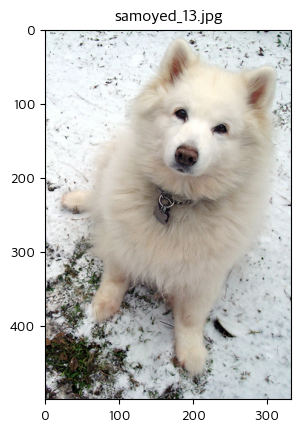

In [77]:
import torchvision

IMAGES_PATH = sorted(glob.glob("./data/images/images/*.jpg"))

print(f"· 이미지 개수: {len(IMAGES_PATH)}개")

rand_idx = random.randint(0, len(IMAGES_PATH))
file_name = IMAGES_PATH[rand_idx].split("/")[-1]
img = torchvision.io.read_image(IMAGES_PATH[rand_idx]).permute(1, 2, 0)

plt.imshow(img)
plt.title(f"{file_name}")
plt.show()

귀엽다

In [529]:
# 분류 작업

import os 

train_label_set = set(TRAIN_LABEL_DICT.keys())
test_label_set = set(TEST_LABEL_DICT.keys())

tmp_image_list = os.listdir("./data/images/images/")
tmp_annot_list = os.listdir("./data/annotations/annotations/xmls/")

all_image_set = set()
all_annot_set = set()

for file_name in tmp_image_list:
    all_image_set.add(file_name.split(".")[0].strip())

for file_name in tmp_annot_list:
    all_annot_set.add(file_name.split(".")[0].strip())

train_image_set = all_image_set & all_annot_set & train_label_set
test_image_set = all_image_set & all_annot_set & test_label_set

train_annot_set = train_image_set & all_annot_set & train_label_set
test_annot_set = test_image_set & (all_annot_set - train_annot_set) & test_label_set

In [530]:
print(f"[train 데이터 오류치 확인]")

warning = "<--" 
blank = ""

print(f"· 이미지 O | label X | 좌표 X: {len(train_image_set - train_label_set - train_annot_set)}개 {warning if len(train_image_set - train_label_set - train_annot_set) != 0 else blank}")
print(f"· 이미지 O | label O | 좌표 X: {len((train_image_set & train_label_set) - train_annot_set)}개 {warning if len((train_image_set & train_label_set) - train_annot_set) != 0 else blank}")
print(f"· 이미지 O | label X | 좌표 O: {len((train_image_set & train_annot_set) - train_label_set)}개 {warning if len((train_image_set & train_annot_set) - train_label_set) != 0 else blank}")
print(f"· 이미지 O | label O | 좌표 O: {len(train_image_set & train_label_set & train_annot_set)}개")
print(f"· 이미지 X | label O | 좌표 O: {len((train_annot_set & train_label_set) - train_image_set)}개 {warning if len((train_annot_set & train_label_set) - train_image_set) != 0 else blank}")
print(f"· 이미지 X | label O | 좌표 X: {len(train_label_set - train_image_set - train_annot_set)}개 {warning if len(train_label_set - train_image_set - train_annot_set) != 0 else blank}")
print(f"· 이미지 X | label X | 좌표 O: {len(train_annot_set - train_image_set - train_label_set)}개 {warning if len(train_annot_set - train_image_set - train_label_set) != 0 else blank}")

[train 데이터 오류치 확인]
· 이미지 O | label X | 좌표 X: 0개 
· 이미지 O | label O | 좌표 X: 0개 
· 이미지 O | label X | 좌표 O: 0개 
· 이미지 O | label O | 좌표 O: 3671개
· 이미지 X | label O | 좌표 O: 0개 
· 이미지 X | label O | 좌표 X: 9개 <--
· 이미지 X | label X | 좌표 O: 0개 


좌표가 할당되지 않은 학습 데이터 9개가 포착되었다.

이는 테스트 데이터로 이용하거나 일절 이용하지 않아야 한다.

In [531]:
print(f"[test 데이터 오류치 확인]")


print(f"· 이미지 O | label X | 좌표 X: {len(test_image_set - test_label_set - test_annot_set)}개 {warning if len(test_image_set - test_label_set - test_annot_set) != 0 else blank}")
print(f"· 이미지 O | label O | 좌표 X: {len((test_image_set & test_label_set) - test_annot_set)}개 {warning if len((test_image_set & test_label_set) - test_annot_set) != 0 else blank}")
print(f"· 이미지 O | label X | 좌표 O: {len((test_image_set & test_annot_set) - test_label_set)}개 {warning if len((test_image_set & test_annot_set) - test_label_set) != 0 else blank}")
print(f"· 이미지 O | label O | 좌표 O: {len(test_image_set & test_label_set & test_annot_set)}개 {warning if len(test_image_set & test_label_set & test_annot_set) == 0 else blank}")
print(f"· 이미지 X | label O | 좌표 O: {len((test_annot_set & test_label_set) - test_image_set)}개 {warning if len((test_annot_set & test_label_set) - test_image_set) != 0 else blank}")
print(f"· 이미지 X | label O | 좌표 X: {len(test_label_set - test_image_set - test_annot_set)}개 {warning if len(test_label_set - test_image_set - test_annot_set) != 0 else blank}")
print(f"· 이미지 X | label X | 좌표 O: {len(test_annot_set - test_image_set - test_label_set)}개 {warning if len(test_annot_set - test_image_set - test_label_set) != 0 else blank}")

[test 데이터 오류치 확인]
· 이미지 O | label X | 좌표 X: 0개 
· 이미지 O | label O | 좌표 X: 0개 
· 이미지 O | label X | 좌표 O: 0개 
· 이미지 O | label O | 좌표 O: 0개 <--
· 이미지 X | label O | 좌표 O: 0개 
· 이미지 X | label O | 좌표 X: 3669개 <--
· 이미지 X | label X | 좌표 O: 0개 


In [377]:
# # 좌표 없는 레이블 리스트
# duck_egg_list = list(train_label_set - all_annot_set)

# TRAIN_IMAGES_PATH = []
# TEST_IMAGES_PATH = []

# train_file_list = list(train_label_set - set(duck_egg_list))
# test_file_list = list(test_label_set)

# for i in duck_egg_list:
#     test_file_list.append(i)

# for i in train_file_list:
#     TRAIN_IMAGES_PATH.append(f"./data/images/images/{i}.jpg")

# for i in test_file_list:
#     TEST_IMAGES_PATH.append(f"./data/images/images/{i}.jpg")

# print(f"· 수정 후 학습 데이터: {len(TRAIN_IMAGES_PATH)}개")
# print(f"· 수정 후 테스트 데이터: {len(TEST_IMAGES_PATH)}개")

· 수정 후 학습 데이터: 3671개
· 수정 후 테스트 데이터: 3678개


- bbox는 xxyy 형식으로 쓰여 있다.